# Pre-entrega Data Science III  
## Pipeline de entrenamiento, validación y clasificador base con PyTorch

**Autora:** Mariana Martinelli  
**Dataset:** AG News Classification  
**Problema:** clasificación multiclase de noticias  
**Framework:** PyTorch  
**Modelo base:** `EmbeddingBag` + MLP  
**Optimizador:** Adam  
**Métrica principal:** Accuracy

---

## Objetivo

Construir un pipeline reproducible de Deep Learning que permita:

- cargar y preparar datos textuales;
- detectar automáticamente CPU, CUDA o MPS;
- fijar semillas de aleatoriedad;
- crear un modelo base con `nn.Module`;
- implementar explícitamente el ciclo de entrenamiento;
- utilizar `zero_grad()`, `backward()` y `optimizer.step()`;
- evaluar el modelo con datos no vistos;
- registrar pérdida y accuracy por época;
- visualizar las curvas de entrenamiento y validación;
- guardar el modelo entrenado;
- realizar predicciones sobre textos nuevos.

> Este checkpoint prioriza la calidad del pipeline por encima de la complejidad del modelo.

## 1. Configuración del entorno


In [7]:
import os
import re
import html
import json
import math
import random
import platform
from pathlib import Path
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Dispositivo seleccionado:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
PyTorch: 2.11.0+cpu
Dispositivo seleccionado: cpu


### Interpretación

El dispositivo se detecta automáticamente:

- `cuda`: GPU NVIDIA;
- `mps`: GPU Apple Silicon;
- `cpu`: procesador convencional.

Todos los tensores y el modelo se moverán al mismo dispositivo mediante `.to(device)`.

## 2. Carga del dataset

In [8]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/CoderHouse/Data Science III")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

if not train_path.exists():
    raise FileNotFoundError(f"No se encontró: {train_path}")

if not test_path.exists():
    raise FileNotFoundError(f"No se encontró: {test_path}")

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

print("Train:", train_raw.shape)
print("Test:", test_raw.shape)

display(train_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (120000, 3)
Test: (7600, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


## 3. Validación inicial de calidad

In [9]:
expected_columns = {"Class Index", "Title", "Description"}

for name, dataframe in [("train", train_raw), ("test", test_raw)]:
    missing = expected_columns - set(dataframe.columns)
    if missing:
        raise ValueError(f"En {name}.csv faltan columnas: {sorted(missing)}")

quality = pd.DataFrame({
    "train_nulos": train_raw.isna().sum(),
    "test_nulos": test_raw.isna().sum(),
    "train_unicos": train_raw.nunique(dropna=False),
    "test_unicos": test_raw.nunique(dropna=False),
})

display(quality)

print("Duplicados completos en train:", train_raw.duplicated().sum())
print("Duplicados completos en test:", test_raw.duplicated().sum())

print("\nDistribución de clases en train:")
print(train_raw["Class Index"].value_counts().sort_index())

print("\nDistribución de clases en test:")
print(test_raw["Class Index"].value_counts().sort_index())

,train_nulos,test_nulos,train_unicos,test_unicos
Class Index,0,0,4,4
Title,0,0,114350,7568
Description,0,0,118723,7594


Duplicados completos en train: 0
Duplicados completos en test: 0

Distribución de clases en train:
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

Distribución de clases en test:
Class Index
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64


El dataset original se conserva sin modificaciones. Las transformaciones se realizan dentro del notebook para asegurar reproducibilidad.

## 4. Limpieza y preparación del texto

In [10]:
CLASS_NAMES = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = text.replace("#36;", "$")
    text = text.replace("\\", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare_dataframe(dataframe):
    data = dataframe.copy()

    data["Title"] = data["Title"].apply(clean_text)
    data["Description"] = data["Description"].apply(clean_text)

    data["text"] = (
        data["Title"].fillna("")
        + " "
        + data["Description"].fillna("")
    ).str.strip()


    data["label"] = data["Class Index"].astype(int) - 1


    data = data[data["text"].str.len() > 0].copy()
    data = data[data["label"].isin(CLASS_NAMES.keys())].copy()

    return data[["text", "label"]].reset_index(drop=True)

train_df = prepare_dataframe(train_raw)
test_df = prepare_dataframe(test_raw)

print("Train preparado:", train_df.shape)
print("Test preparado:", test_df.shape)
display(train_df.head())

Train preparado: (120000, 2)
Test preparado: (7600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


## 5. Muestreo estratificado y separación train/validation

In [11]:
# Para este checkpoint se usa una muestra controlada para acelerar el entrenamiento.
# Cambiar a None para utilizar las 120.000 noticias.
MAX_TRAIN_SAMPLES = 40000

if MAX_TRAIN_SAMPLES is not None and len(train_df) > MAX_TRAIN_SAMPLES:
    train_work, _ = train_test_split(
        train_df,
        train_size=MAX_TRAIN_SAMPLES,
        stratify=train_df["label"],
        random_state=SEED,
    )
    train_work = train_work.reset_index(drop=True)
else:
    train_work = train_df.copy()

train_split, val_split = train_test_split(
    train_work,
    test_size=0.20,
    stratify=train_work["label"],
    random_state=SEED,
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print("Entrenamiento:", train_split.shape)
print("Validación:", val_split.shape)
print("Prueba final:", test_df.shape)

print("\nDistribución train:")
print(train_split["label"].value_counts(normalize=True).sort_index().round(4))

print("\nDistribución validación:")
print(val_split["label"].value_counts(normalize=True).sort_index().round(4))

Entrenamiento: (32000, 2)
Validación: (8000, 2)
Prueba final: (7600, 2)

Distribución train:
label
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64

Distribución validación:
label
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64


`test.csv` no se usa durante las épocas. Solo se utiliza al final para obtener una evaluación independiente.

## 6. Tokenización y vocabulario

In [12]:
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9]+(?:['-][A-Za-z0-9]+)?|[^\w\s]")

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

MIN_FREQ = 2
MAX_VOCAB_SIZE = 50000

counter = Counter()

for text in train_split["text"]:
    counter.update(tokenize(text))

most_common_tokens = [
    token
    for token, freq in counter.most_common(MAX_VOCAB_SIZE - 2)
    if freq >= MIN_FREQ
]

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token in most_common_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]

print("Tamaño del vocabulario:", len(vocab))
print("Ejemplo de tokens:", tokenize(train_split.loc[0, "text"])[:20])

Tamaño del vocabulario: 28795
Ejemplo de tokens: ['mexico', '#', '39', ';', 's', 'cemex', 'may', 'sell', 'two', 'us', 'plants', 'mexican', 'cement', 'company', 'cemex', 'sa', 'said', 'monday', 'it', 'has']


El vocabulario se construye únicamente con el conjunto de entrenamiento para evitar fuga de información.

## 7. Dataset y DataLoader

In [13]:
def encode_text(text):
    token_ids = [vocab.get(token, UNK_IDX) for token in tokenize(text)]
    if not token_ids:
        token_ids = [UNK_IDX]
    return token_ids


class AGNewsDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "token_ids": encode_text(self.texts[index]),
            "label": self.labels[index],
            "text": self.texts[index],
        }


def collate_batch(batch):
    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.long,
    )

    offsets = [0]
    flat_tokens = []

    for item in batch:
        token_ids = item["token_ids"]
        flat_tokens.extend(token_ids)
        offsets.append(offsets[-1] + len(token_ids))

    offsets = torch.tensor(offsets[:-1], dtype=torch.long)
    text_tensor = torch.tensor(flat_tokens, dtype=torch.long)

    return text_tensor, offsets, labels


BATCH_SIZE = 128
NUM_WORKERS = 0

train_dataset = AGNewsDataset(train_split)
val_dataset = AGNewsDataset(val_split)
test_dataset = AGNewsDataset(test_df)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS,
)

batch_text, batch_offsets, batch_labels = next(iter(train_loader))

print("Tokens concatenados:", batch_text.shape)
print("Offsets:", batch_offsets.shape)
print("Etiquetas:", batch_labels.shape)

Tokens concatenados: torch.Size([5746])
Offsets: torch.Size([128])
Etiquetas: torch.Size([128])


## 8. Arquitectura base

In [14]:
class TextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        dropout=0.25,
    ):
        super().__init__()

        self.embedding = nn.EmbeddingBag(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            mode="mean",
            sparse=False,
        )

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.5, 0.5)

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        logits = self.classifier(embedded)
        return logits


EMBEDDING_DIM = 128
HIDDEN_DIM = 64
NUM_CLASSES = 4
DROPOUT = 0.25

model = TextClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(device)

print(model)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Parámetros entrenables: {total_parameters:,}")

TextClassifier(
  (embedding): EmbeddingBag(28795, 128, mode='mean')
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Parámetros entrenables: 3,694,276


La arquitectura utiliza:

1. `EmbeddingBag` para representar cada noticia mediante el promedio de sus embeddings;
2. una capa lineal;
3. activación ReLU;
4. Dropout;
5. una capa final con cuatro salidas.

No se aplica `Softmax` dentro del modelo porque `CrossEntropyLoss` espera logits.

## 9. Funciones de entrenamiento y validación

In [15]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for text, offsets, labels in data_loader:
        text = text.to(device)
        offsets = offsets.to(device)
        labels = labels.to(device)

        # Reinicia los gradientes
        optimizer.zero_grad()

        # Forward pass.
        logits = model(text, offsets)

        # Cálculo de la pérdida.
        loss = criterion(logits, labels)

        # Backpropagation mediante torch.autograd.
        loss.backward()

        # Actualización de los pesos.
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)

        all_predictions.extend(predictions.detach().cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())

    epoch_loss = total_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for text, offsets, labels in data_loader:
        text = text.to(device)
        offsets = offsets.to(device)
        labels = labels.to(device)

        logits = model(text, offsets)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    epoch_loss = total_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy, all_labels, all_predictions

## 10. Configuración del entrenamiento

In [16]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 8
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Optimizador:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Épocas:", NUM_EPOCHS)

Optimizador: Adam
Learning rate: 0.001
Épocas: 8


## 11. Training loop y tracking

In [17]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

best_val_loss = float("inf")
best_model_path = Path("best_agnews_model.pt")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_accuracy, _, _ = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device,
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "vocab": vocab,
            "class_names": CLASS_NAMES,
            "config": {
                "embedding_dim": EMBEDDING_DIM,
                "hidden_dim": HIDDEN_DIM,
                "num_classes": NUM_CLASSES,
                "dropout": DROPOUT,
                "learning_rate": LEARNING_RATE,
                "seed": SEED,
            },
            "best_val_loss": best_val_loss,
            "epoch": epoch,
        }

        torch.save(checkpoint, best_model_path)

    print(
        f"Época {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("\nEntrenamiento finalizado.")
print("Mejor checkpoint:", best_model_path)
print("Mejor val loss:", round(best_val_loss, 4))

Época 01/8 | Train Loss: 0.9086 | Train Acc: 0.6716 | Val Loss: 0.4349 | Val Acc: 0.8596
Época 02/8 | Train Loss: 0.3532 | Train Acc: 0.8878 | Val Loss: 0.3334 | Val Acc: 0.8934
Época 03/8 | Train Loss: 0.2611 | Train Acc: 0.9199 | Val Loss: 0.3109 | Val Acc: 0.8964
Época 04/8 | Train Loss: 0.2145 | Train Acc: 0.9364 | Val Loss: 0.3048 | Val Acc: 0.8984
Época 05/8 | Train Loss: 0.1828 | Train Acc: 0.9469 | Val Loss: 0.3065 | Val Acc: 0.8976
Época 06/8 | Train Loss: 0.1571 | Train Acc: 0.9555 | Val Loss: 0.3184 | Val Acc: 0.8940
Época 07/8 | Train Loss: 0.1408 | Train Acc: 0.9587 | Val Loss: 0.3219 | Val Acc: 0.8928
Época 08/8 | Train Loss: 0.1241 | Train Acc: 0.9642 | Val Loss: 0.3353 | Val Acc: 0.8899

Entrenamiento finalizado.
Mejor checkpoint: best_agnews_model.pt
Mejor val loss: 0.3048


## 12. Curvas de pérdida y accuracy

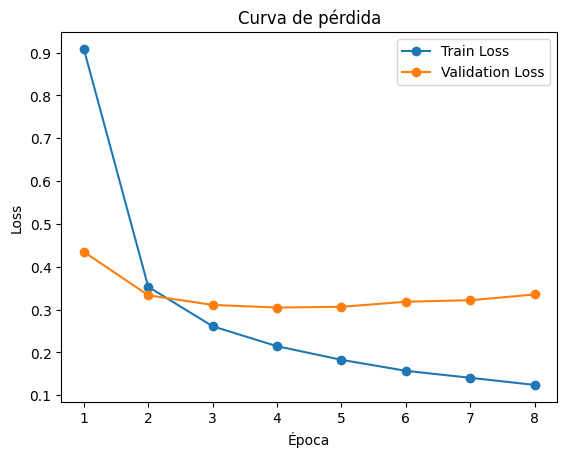

In [18]:
epochs = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots()
ax.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
ax.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
ax.set_title("Curva de pérdida")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

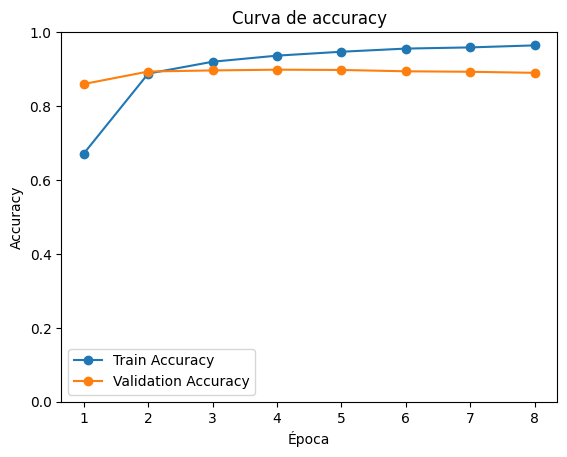

In [19]:
fig, ax = plt.subplots()
ax.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
ax.set_title("Curva de accuracy")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.show()

### Interpretación esperada

- Si la pérdida de entrenamiento y validación disminuyen, el modelo está aprendiendo.
- Si la pérdida de entrenamiento sigue bajando pero la de validación sube, puede existir overfitting.
- Una diferencia excesiva entre accuracy de entrenamiento y validación también puede indicar sobreajuste.

La interpretación final debe basarse en los valores obtenidos después de ejecutar el notebook.

## 13. Cargar el mejor checkpoint

In [20]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False,
)

best_model = TextClassifier(
    vocab_size=len(checkpoint["vocab"]),
    embedding_dim=checkpoint["config"]["embedding_dim"],
    hidden_dim=checkpoint["config"]["hidden_dim"],
    num_classes=checkpoint["config"]["num_classes"],
    dropout=checkpoint["config"]["dropout"],
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Checkpoint cargado.")
print("Mejor época:", checkpoint["epoch"])
print("Mejor validation loss:", round(checkpoint["best_val_loss"], 4))

Checkpoint cargado.
Mejor época: 4
Mejor validation loss: 0.3048


## 14. Evaluación final sobre test.csv

In [21]:
test_loss, test_accuracy, test_labels, test_predictions = evaluate(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3095
Test Accuracy: 0.9020


In [22]:
target_names = [CLASS_NAMES[index] for index in range(NUM_CLASSES)]

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=target_names,
        digits=4,
    )
)

              precision    recall  f1-score   support

       World     0.9146    0.9074    0.9110      1900
      Sports     0.9426    0.9684    0.9553      1900
    Business     0.8807    0.8468    0.8634      1900
    Sci/Tech     0.8688    0.8853    0.8770      1900

    accuracy                         0.9020      7600
   macro avg     0.9017    0.9020    0.9017      7600
weighted avg     0.9017    0.9020    0.9017      7600



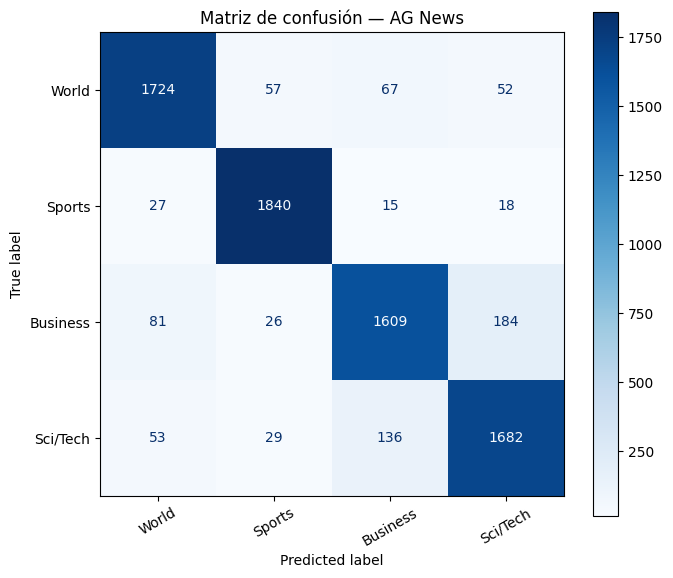

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=target_names,
    cmap="Blues",
    ax=ax,
    xticks_rotation=30,
)

ax.set_title("Matriz de confusión — AG News")
plt.tight_layout()
plt.show()

## 15. Predicción sobre textos nuevos

In [24]:
def predict_text(text, model, vocab, device):
    model.eval()

    cleaned = clean_text(text)
    token_ids = [
        vocab.get(token, UNK_IDX)
        for token in tokenize(cleaned)
    ]

    if not token_ids:
        token_ids = [UNK_IDX]

    text_tensor = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device,
    )

    offsets = torch.tensor(
        [0],
        dtype=torch.long,
        device=device,
    )

    with torch.no_grad():
        logits = model(text_tensor, offsets)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = int(probabilities.argmax(dim=1).item())
        confidence = float(probabilities[0, predicted_class].item())

    return {
        "class_id": predicted_class,
        "class_name": CLASS_NAMES[predicted_class],
        "confidence": confidence,
    }


examples = [
    "The government announced a new international agreement after the summit.",
    "The football team won the championship after a dramatic final match.",
    "The company reported higher quarterly profits and stronger sales.",
    "Scientists introduced a new artificial intelligence system for medical research.",
]

for example in examples:
    result = predict_text(
        text=example,
        model=best_model,
        vocab=vocab,
        device=device,
    )

    print("\nTexto:", example)
    print("Predicción:", result)


Texto: The government announced a new international agreement after the summit.
Predicción: {'class_id': 0, 'class_name': 'World', 'confidence': 0.8739555478096008}

Texto: The football team won the championship after a dramatic final match.
Predicción: {'class_id': 1, 'class_name': 'Sports', 'confidence': 0.9999794960021973}

Texto: The company reported higher quarterly profits and stronger sales.
Predicción: {'class_id': 2, 'class_name': 'Business', 'confidence': 0.9993941783905029}

Texto: Scientists introduced a new artificial intelligence system for medical research.
Predicción: {'class_id': 3, 'class_name': 'Sci/Tech', 'confidence': 0.9902100563049316}


## 16. Guardado de artefactos

In [25]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_model_path = artifacts_dir / "agnews_text_classifier.pt"
vocab_path = artifacts_dir / "vocab.json"
history_path = artifacts_dir / "training_history.json"

torch.save(checkpoint, final_model_path)

with open(vocab_path, "w", encoding="utf-8") as file:
    json.dump(vocab, file, ensure_ascii=False)

with open(history_path, "w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

print("Modelo:", final_model_path)
print("Vocabulario:", vocab_path)
print("Historial:", history_path)

Modelo: artifacts/agnews_text_classifier.pt
Vocabulario: artifacts/vocab.json
Historial: artifacts/training_history.json


## 17. Conclusiones

Este checkpoint implementa un pipeline funcional de entrenamiento y validación en PyTorch.

Se cumplieron los siguientes requisitos:

- detección automática de CPU, CUDA o MPS;
- semillas para reproducibilidad;
- arquitectura definida con `nn.Module`;
- uso de `EmbeddingBag`, capas lineales, ReLU y Dropout;
- forward pass explícito;
- cálculo de pérdida con `CrossEntropyLoss`;
- reinicio de gradientes con `optimizer.zero_grad()`;
- backpropagation mediante `loss.backward()`;
- actualización de pesos con Adam;
- evaluación separada en validación;
- tracking de loss y accuracy por época;
- evaluación final sobre test;
- guardado del mejor modelo;
- función de inferencia para textos nuevos.

### Interpretación de la curva de pérdida

> La pérdida de entrenamiento disminuyó de manera sostenida durante las ocho épocas, lo que indica que el modelo aprendió correctamente sobre los datos de entrenamiento. La pérdida de validación también descendió al comienzo y alcanzó su mejor valor en la época 4, con 0,3048. A partir de la época 5 comenzó a aumentar, mientras que la pérdida de entrenamiento continuó bajando. Esta divergencia indica un sobreajuste moderado. Por este motivo, el mejor checkpoint corresponde a la época 4 y convendría aplicar early stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.

### Limitaciones

- El modelo usa una tokenización simple.
- No utiliza embeddings preentrenados.
- No captura el orden completo de las palabras.
- El vocabulario se construye localmente.
- El checkpoint utiliza una muestra de entrenamiento para reducir el tiempo de ejecución.
- En futuras entregas puede evolucionar hacia LSTM, GRU o Transformers.